In [3]:
import pandas as pd
import os

# Check exact dataset folder path
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [5]:
import pandas as pd
import glob

# Automatically find train.csv inside Kaggle input folders
train_path = glob.glob('/kaggle/input/**/train.csv', recursive=True)[0]

print("Dataset path:", train_path)

# Load dataset
train = pd.read_csv(train_path)

# Show first 5 rows
train.head()

Dataset path: /kaggle/input/competitions/titanic/train.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
print("Dataset Shape:", train.shape)

print("\nColumns:")
print(train.columns)

print("\nDataset Information:")
train.info()

print("\nMissing Values:")
print(train.isnull().sum())

Dataset Shape: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      

Original Dataset Shape: (891, 12)

Missing Values After Cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Dataset After Preprocessing:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize
0,0,3,0,22.0,1,0,7.2500,0,2
1,1,1,1,38.0,1,0,71.2833,1,2
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,2
4,0,3,0,35.0,0,0,8.0500,0,1



Input Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']

Target Column:
Survived

Training Data Shape: (712, 8)
Testing Data Shape: (179, 8)

LOGISTIC REGRESSION RESULTS
Accuracy: 80.45 %

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



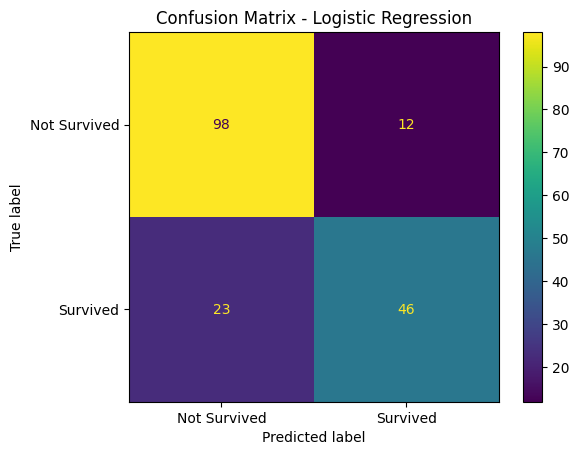


RANDOM FOREST RESULTS
Accuracy: 81.56 %

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



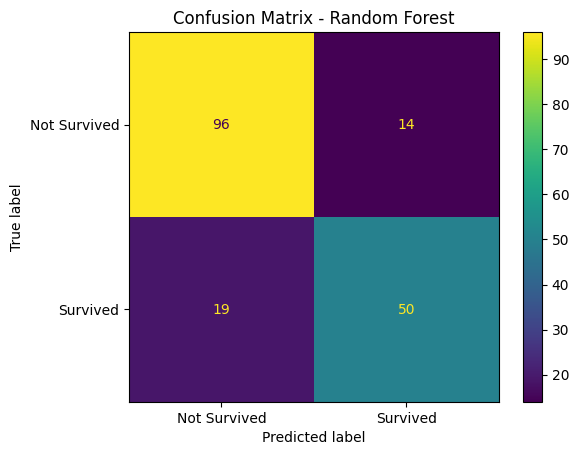


MODEL COMPARISON


,Model,Accuracy (%)
0,Logistic Regression,80.45
1,Random Forest,81.56



Best Model: Random Forest with accuracy: 81.56 %


In [7]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ----------------------------------------------------------
# DATA CLEANING
# ----------------------------------------------------------

# Create a copy so original data remains safe
df = train.copy()

print("Original Dataset Shape:", df.shape)

# Remove columns that are not useful for simple prediction
df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], inplace=True)

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# ----------------------------------------------------------
# FEATURE ENGINEERING
# ----------------------------------------------------------

# Create a new feature: total family members traveling together
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Convert categorical text columns into numeric form
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

print("\nDataset After Preprocessing:")
display(df.head())

# ----------------------------------------------------------
# SELECT INPUT FEATURES AND TARGET
# ----------------------------------------------------------

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize"
]

X = df[features]
y = df["Survived"]

print("\nInput Features:")
print(X.columns.tolist())

print("\nTarget Column:")
print("Survived")

# ----------------------------------------------------------
# SPLIT DATA INTO TRAINING AND TESTING SETS
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# ----------------------------------------------------------
#  SCALE THE DATA FOR LOGISTIC REGRESSION
# ----------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ----------------------------------------------------------
#  TRAIN LOGISTIC REGRESSION MODEL
# ----------------------------------------------------------

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("\n" + "=" * 55)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 55)
print("Accuracy:", round(logistic_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))

# Confusion Matrix
cm_logistic = confusion_matrix(y_test, logistic_predictions)

display_logistic = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Survived", "Survived"]
)

display_logistic.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# ----------------------------------------------------------
# TRAIN RANDOM FOREST MODEL
# ----------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("\n" + "=" * 55)
print("RANDOM FOREST RESULTS")
print("=" * 55)
print("Accuracy:", round(rf_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_predictions)

display_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not Survived", "Survived"]
)

display_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ----------------------------------------------------------
#  COMPARE BOTH MODELS
# ----------------------------------------------------------

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy (%)": [
        round(logistic_accuracy * 100, 2),
        round(rf_accuracy * 100, 2)
    ]
})

print("\n" + "=" * 55)
print("MODEL COMPARISON")
print("=" * 55)

display(results)

# Find best model
best_model = results.loc[results["Accuracy (%)"].idxmax()]

print(
    "\nBest Model:",
    best_model["Model"],
    "with accuracy:",
    best_model["Accuracy (%)"],
    "%"
)

In [9]:
# ==========================================================
# FINAL PREDICTIONS ON UNSEEN TEST DATA
# ==========================================================

import glob
import pandas as pd

# Find and load Kaggle test.csv file
test_path = glob.glob('/kaggle/input/**/test.csv', recursive=True)[0]
test_data = pd.read_csv(test_path)

# Keep PassengerId for final prediction file
passenger_ids = test_data["PassengerId"]

# Remove columns that were not used in training
test_clean = test_data.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"]
)

# Handle missing values exactly like training data
test_clean["Age"] = test_clean["Age"].fillna(df["Age"].median())
test_clean["Embarked"] = test_clean["Embarked"].fillna(df["Embarked"].mode()[0])
test_clean["Fare"] = test_clean["Fare"].fillna(df["Fare"].median())

# Create FamilySize feature
test_clean["FamilySize"] = test_clean["SibSp"] + test_clean["Parch"] + 1

# Convert text values into numbers
test_clean["Sex"] = test_clean["Sex"].map({
    "male": 0,
    "female": 1
})

test_clean["Embarked"] = test_clean["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

# Select same features that were used for model training
X_final_test = test_clean[features]

# Use the best model: Random Forest
final_predictions = random_forest_model.predict(X_final_test)

# Create final results file
submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": final_predictions
})

display(submission.head(10))

# Save file in Kaggle output
submission.to_csv(
    "/kaggle/working/titanic_survival_predictions.csv",
    index=False
)

print("Prediction file created successfully!")
print("File name: titanic_survival_predictions.csv")

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


Prediction file created successfully!
File name: titanic_survival_predictions.csv
